In [ ]:

!pip install catboost
pip install xgboost

In [ ]:
pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 1.1 MB/s  0:00:03 eta 0:00:010m

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:

import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Load data
X = pd.read_csv('../data/processed/X_engineered_final.csv')
y = pd.read_csv('../data/processed/y_final.csv')

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

# Save
os.makedirs('../data/split', exist_ok=True)

X_train.to_csv('../data/split/X_train.csv', index=False)
X_test.to_csv('../data/split/X_test.csv', index=False)
y_train.to_csv('../data/split/y_train.csv', index=False)
y_test.to_csv('../data/split/y_test.csv', index=False)

print(" Data split saved")

Train: (52428, 52)
Test: (13107, 52)
 Data split saved


In [19]:
pip install --upgrade xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:


import pandas as pd
import numpy as np
import joblib
import os
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Step 1: Libraries imported")

# ---------------------------------------
# Load split data
# ---------------------------------------
X_train = pd.read_csv('../data/split/X_train.csv')
X_test  = pd.read_csv('../data/split/X_test.csv')
y_train = pd.read_csv('../data/split/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/split/y_test.csv').values.ravel()

print("Step 2: Data loaded")

# ---------------------------------------
# Identify numeric & categorical
# ---------------------------------------
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns

# ---------------------------------------
# Preprocess
# ---------------------------------------
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Step 3: Preprocessing done")

# ---------------------------------------
# Log transform target
# ---------------------------------------
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# ---------------------------------------
# Convert to DMatrix
# ---------------------------------------
dtrain = xgb.DMatrix(X_train_processed, label=y_train_log)
dtest  = xgb.DMatrix(X_test_processed, label=y_test_log)

# ---------------------------------------
# XGBoost parameters
# ---------------------------------------
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.03,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'alpha': 0.1,
    'lambda': 1,
    'seed': 42,
    'eval_metric': 'rmse'
}

# ---------------------------------------
# Train model
# ---------------------------------------
evallist = [(dtrain, 'train'), (dtest, 'eval')]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evallist,
    early_stopping_rounds=50,
    verbose_eval=False  
)

print("Step 4: Model trained")

# ---------------------------------------
# Predict & inverse log
# ---------------------------------------
y_pred_log = bst.predict(dtest)
y_pred = np.expm1(y_pred_log)

# ---------------------------------------
# Evaluation
# ---------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

epsilon = 1e-10

mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100
smape = 100 * np.mean(
    2 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred) + epsilon)
)

# ---------------------------------------
# Store results in DataFrame (LIKE BASELINE)
# ---------------------------------------
results = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "MAPE (%)": [mape],
    "SMAPE (%)": [smape]
}, index=["XGBoost"])

# ---------------------------------------
# Print results
# ---------------------------------------
print("\n XGBoost Results:")
print(results)

# ---------------------------------------
# Save model & preprocessor
# ---------------------------------------
os.makedirs('../models', exist_ok=True)
bst.save_model('../models/xgb_model_dmatrix.json')
joblib.dump(preprocessor, '../models/preprocessor.pkl')

print("\n XGBoost model saved")

Step 1: Libraries imported


Step 2: Data loaded
Step 3: Preprocessing done
Step 4: Model trained

 XGBoost Results:
                MAE        RMSE        R2   MAPE (%)  SMAPE (%)
XGBoost  144.512619  371.813364  0.580786  13.727022  13.529945

 XGBoost model saved


In [ ]:
# ===============================
# RANDOM FOREST
# ===============================

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Step 1: Load split data")

X_train = pd.read_csv('../data/split/X_train.csv')
X_test  = pd.read_csv('../data/split/X_test.csv')
y_train = pd.read_csv('../data/split/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/split/y_test.csv').values.ravel()

# Columns
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

print("Step 2: Train RF")

model = RandomForestRegressor(
    n_estimators=400,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_p, y_train)

# Predict
y_pred = model.predict(X_test_p)

# Metrics
epsilon = 1e-10

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100
smape = 100 * np.mean(
    2 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred) + epsilon)
)

print("\nRandom Forest Results:")
print("R2 :", round(r2,4))
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2), "%")
print("SMAPE:", round(smape,2), "%")

# Save
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/random_forest.pkl')

Step 1: Load split data
Step 2: Train RF

📊 Random Forest Results:
R2 : 0.5513
MAE: 160.9
RMSE: 384.69
MAPE: 15.8 %
SMAPE: 14.76 %


['../models/random_forest.pkl']

In [16]:
joblib.dump(preprocessor, '../models/rf_preprocessor.pkl')  
joblib.dump(model, '../models/random_forest.pkl')

['../models/random_forest.pkl']

In [ ]:
# ===============================
# LIGHTGBM FINAL (SAVE WITH CATEGORY INFO)
# ===============================

import pandas as pd
import numpy as np
import os
import lightgbm as lgb
import joblib

print("Loading data...")

X_train = pd.read_csv('../data/split/X_train.csv')
X_test  = pd.read_csv('../data/split/X_test.csv')
y_train = pd.read_csv('../data/split/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/split/y_test.csv').values.ravel()

# ✅ categorical columns
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# ✅ convert to category + align
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')
    X_test[col]  = X_test[col].cat.set_categories(X_train[col].cat.categories)

# ✅ SAVE CATEGORY VALUES (VERY IMPORTANT)
cat_values = {
    col: list(X_train[col].cat.categories)
    for col in cat_cols
}

# log transform
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

train_data = lgb.Dataset(X_train, label=y_train_log, categorical_feature=cat_cols)
test_data  = lgb.Dataset(X_test,  label=y_test_log,  categorical_feature=cat_cols)

print("Training...")

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 128,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'seed': 42
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, test_data],
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

# ===============================
# SAVE MODEL (CRITICAL FIX)
# ===============================

os.makedirs('../models', exist_ok=True)

joblib.dump({
    "model": model,
    "cat_cols": cat_cols,
    "feature_cols": list(X_train.columns),
    "cat_values": cat_values   # 🔥 MOST IMPORTANT
}, '../models/best_model.pkl')

print("✅ Model saved correctly")

Loading data...


Training...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5447
[LightGBM] [Info] Number of data points in the train set: 52428, number of used features: 51
[LightGBM] [Info] Start training from score 6.613759
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 0.209747	valid_1's rmse: 0.222981
[200]	training's rmse: 0.187391	valid_1's rmse: 0.210361
[300]	training's rmse: 0.17646	valid_1's rmse: 0.20775
[400]	training's rmse: 0.16804	valid_1's rmse: 0.206011
[500]	training's rmse: 0.161038	valid_1's rmse: 0.204938
[600]	training's rmse: 0.154752	valid_1's rmse: 0.204187
[700]	training's rmse: 0.149193	valid_1's rmse: 0.203864
[800]	training's rmse: 0.144119	valid_1's rmse: 0.203602
[900]	training's rmse: 0.139504	valid_1's rmse: 0.203565
[1000]	training's rmse: 0.135254	valid_1's rmse: 0.203404
[1100]	training'

In [3]:
import joblib

# Save best model
joblib.dump({
    "model": model,
    "cat_cols": cat_cols
}, "../models/best_model.pkl")

# Save average premium
avg_premium = y_train.mean()
joblib.dump(avg_premium, "../models/avg_premium.pkl")

print("Best model saved")

Best model saved


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import os

# 1. Load the trained model and the original training data to match categories
model = lgb.Booster(model_file='../models/lightgbm_model.txt')
X_train = pd.read_csv('../data/split/X_train.csv') # Needed to align categorical types

# 2. Define your specific input (ID 1_2)
# Ensure the column names here match your CSV exactly
raw_data = {
    'ID': '1_2',
    'period': 1,
    'exposure_time': 1,
    'seniority_insured': 24,
    'seniority_policy': 24,
    'gender': 'F',
    'age': 80,
    'cost_claims_year': 1930.11,
    'n_medical_services': 344.41,
    'type_policy': 'I',
    'type_product': 'S',
    'reimbursement': 'No',
    'new_business': 'No',
    # ... add any other columns your model uses below ...
}

# 3. Create DataFrame and Align Columns
input_df = pd.DataFrame([raw_data])

# IMPORTANT: LightGBM needs the exact same columns as training
# We filter the input to only the columns the model expects
model_features = model.feature_name()
input_df = input_df.reindex(columns=model_features)

# 4. Handle Categorical Columns (Match X_train types)
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if col in input_df.columns:
        input_df[col] = input_df[col].astype('category')
        # This aligns the internal "codes" for categories to match training
        input_df[col] = input_df[col].cat.set_categories(X_train[col].astype('category').cat.categories)

# 5. Predict (The result will be in Log Scale)
pred_log = model.predict(input_df)

# 6. Back-Transform (Reverse Log1p)
# Since you used np.log1p during training, we must use np.expm1
final_premium = np.expm1(pred_log)[0]

print("-" * 30)
print(f"Prediction for ID 1_2:")
print(f"Predicted Premium: {round(final_premium, 2)}")
print("-" * 30)

------------------------------
Prediction for ID 1_2:
Predicted Premium: 955.54
------------------------------


📂 Loading data...
🚀 Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5447
[LightGBM] [Info] Number of data points in the train set: 52428, number of used features: 51
[LightGBM] [Info] Start training from score 885.345125
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 322.968	valid_1's rmse: 378.472
[200]	training's rmse: 298.675	valid_1's rmse: 378.172
[300]	training's rmse: 281.575	valid_1's rmse: 379.726
Early stopping, best iteration is:
[215]	training's rmse: 296.08	valid_1's rmse: 377.834
📊 Evaluating model...

📊 MODEL PERFORMANCE:
                 MAE        RMSE      R²   MAPE (%)  SMAPE (%)
LightGBM  164.261103  377.834066  0.5671  18.153999   16.92991


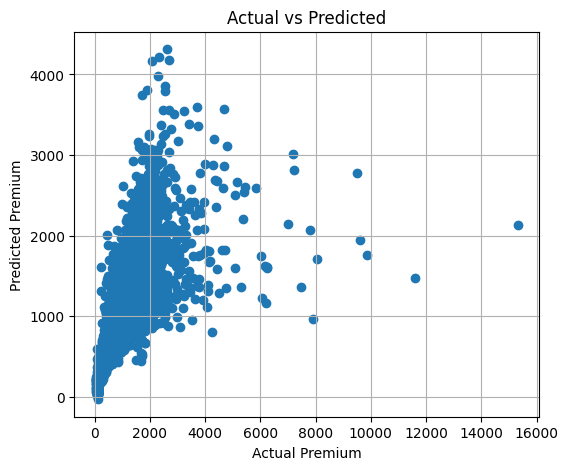


✅ Model saved successfully


In [7]:
# =====================================================
# FINAL LIGHTGBM (WITH FULL METRICS + CLEAN OUTPUT)
# =====================================================

import pandas as pd
import numpy as np
import os
import lightgbm as lgb
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

print("📂 Loading data...")

X_train = pd.read_csv('../data/split/X_train.csv')
X_test  = pd.read_csv('../data/split/X_test.csv')
y_train = pd.read_csv('../data/split/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/split/y_test.csv').values.ravel()

# =====================================================
# CATEGORICAL FEATURES
# =====================================================

cat_cols = X_train.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')
    X_test[col]  = X_test[col].cat.set_categories(X_train[col].cat.categories)

cat_values = {
    col: list(X_train[col].cat.categories)
    for col in cat_cols
}

# =====================================================
# TRAIN MODEL
# =====================================================

print("🚀 Training LightGBM...")

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
test_data  = lgb.Dataset(X_test, label=y_test, categorical_feature=cat_cols)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': -1,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, test_data],
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

# =====================================================
# PREDICTION
# =====================================================

print("📊 Evaluating model...")

y_pred = model.predict(X_test)

# =====================================================
# METRICS
# =====================================================

epsilon = 1e-10

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 🔥 MAPE (IMPORTANT)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# 🔥 SMAPE (better than MAPE sometimes)
smape = 100 * np.mean(
    2 * np.abs(y_pred - y_test) /
    (np.abs(y_test) + np.abs(y_pred) + epsilon)
)

# =====================================================
# PRINT RESULTS
# =====================================================

results = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2],
    "MAPE (%)": [mape],
    "SMAPE (%)": [smape]
}, index=["LightGBM"])

print("\n📊 MODEL PERFORMANCE:")
print(results)

# =====================================================
# VISUALIZATION (IMPORTANT FOR REPORT)
# =====================================================

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Premium")
plt.ylabel("Predicted Premium")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

# =====================================================
# SAVE MODEL
# =====================================================

os.makedirs('../models', exist_ok=True)

joblib.dump({
    "model": model,
    "feature_cols": list(X_train.columns),
    "cat_cols": cat_cols,
    "cat_values": cat_values
}, '../models/best_model.pkl')

print("\n✅ Model saved successfully")